# Task 1 — Symbolic Unconditioned Music Generation
## Two-Stage Aria LoRA Fine-tuning: Full Experiment Log & Analysis

**Course:** CSE 153 / 253 · Assignment 2  
**Method:** Pretrained Aria (symbolic MIDI Transformer) → Stage 1 MAESTRO LoRA → Stage 2 Chopin Étude LoRA  
**Evaluation metric:** Cross-entropy loss + next-token accuracy on Chopin Étude test split  

### Summary
Our work demonstrates that **two-stage LoRA fine-tuning** of a pretrained symbolic MIDI Transformer can produce measurable improvements over both the base model and single-stage fine-tuning, even with fewer than 60 training files. The dominant finding — that learning rate is a more important regulariser than dropout in this regime — has practical implications for future style-transfer experiments with MIDI Transformers. The generated music is musically plausible (moderate KL divergence, reasonable note density) but not yet stylistically precise, suggesting that larger LoRA rank, longer generation sequences, and expanded training data are the most promising directions for future improvement.

### Reading Guide

| Section | Content |
|---|---|
| §1 | Data collection, pre-processing, and exploratory analysis |
| §2 | Modeling: problem formulation, Aria + LoRA, two-stage strategy |
| §3 | Evaluation: metrics, baselines, results, and generated MIDI analysis |
| §4 | Discussion of related work |

---
## §1 — Data Collection, Pre-processing, and Exploratory Analysis

### 1.1 The MAESTRO Dataset

**Source and collection methodology.**  
The **MAESTRO** (*MIDI and Audio Edited for Synchronous TRacks and Organization*) dataset was introduced by Hawthorne et al. (2019) and is publicly available from the Magenta project at Google Brain. It was collected over several years at the *International Piano-e-Competition*, where participants perform on Yamaha Diskklavier grand pianos — instruments equipped with optical sensors that record every key press and release with sub-millisecond precision. The resulting MIDI files are therefore a faithful representation of actual concert performances, free from the manual annotation errors common in MIDI datasets assembled from the internet.

The dataset (v3) comprises approximately **200 hours** of solo piano music across 1,282 MIDI/audio pairs drawn from 172 composers. Each entry includes: (1) a high-resolution MIDI file, (2) a 44.1 kHz WAV recording, (3) aligned text annotations, and (4) metadata fields such as `canonical_composer`, `canonical_title`, `split`, and `duration`. The standard train/validation/test split follows a roughly 80/10/10 partition by performer, ensuring that performances by the same pianist do not appear in multiple splits — a design choice that prevents memorisation of performer-specific idiosyncrasies.

**Why MAESTRO for pre-training?**  
For our task of learning a Chopin-style music distribution, MAESTRO serves an ideal role as a *broad domain* corpus: it provides the model with a rich prior over classical piano idioms — harmonic vocabulary, articulation patterns, rhythmic structures — before the model is exposed to style-specific data. This mirrors the strategy used in natural language processing, where models are first pre-trained on a large general corpus before being fine-tuned on a specialised domain.

### 1.2 The Chopin Étude Subset

For the second stage of fine-tuning, we construct a **Chopin Étude subset** by filtering MAESTRO's metadata for entries whose `canonical_composer` contains "Chopin" and whose `canonical_title` contains "Étude" or "Etude". This yields **68 entries** spanning Op. 10 and Op. 25, recorded between 2004 and 2017.

Chopin's études are an appropriate stylistic target for several reasons:
- They exhibit highly consistent and recognisable musical features: rapid figurations, specific arpeggiation patterns, and a dense note-per-second rate that is unusual among classical piano repertoire.
- The same étude is performed by multiple pianists in MAESTRO, providing mild data augmentation: the model sees the same underlying score interpreted with different timing and dynamics.
- The task of learning the Chopin étude distribution is demanding enough to test whether LoRA fine-tuning can capture style-specific features, but not so obscure that evaluation becomes subjective.

### 1.3 Data Pre-processing Pipeline

**MIDI tokenisation.**  
Raw MIDI files are tokenised using the **Aria tokeniser**, which converts a MIDI file into a sequence of discrete integer tokens representing note events, velocity classes, and time shifts. This tokenisation scheme is analogous to byte-pair encoding (BPE) in text: musical events are encoded as compact tokens that balance expressivity with sequence length. A key design choice is the block size of **512 tokens**, which corresponds to roughly 5–15 seconds of music depending on note density. Training sequences are randomly sampled from within each MIDI file, enabling data augmentation through positional diversity.

**No audio processing is required:** since both MAESTRO and the Chopin subset are used in their symbolic (MIDI) form, there is no spectrogram computation, no onset detection, and no pitch extraction. This is one of the primary advantages of the symbolic modality for a generation task — the input representation is already discrete and structured.

**Train/validation/test assignment** follows the original MAESTRO splits. For the Chopin subset specifically, the split distribution is highly imbalanced (59 train / 3 validation / 6 test), a consequence of MAESTRO's performer-level splitting strategy. As we discuss in §1.5, this small test set has important consequences for evaluation noise.

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path('..').resolve()          # Music-Feature/
PLOTS = ROOT / 'Task1/result/plots'
RESULTS = ROOT / 'Task1/result'

# ── colour palette (consistent across all plots) ─────────────────────────────
C_S1    = '#2980b9'   # Stage 1 / blue
C_S2    = '#27ae60'   # Stage 2 final / green
C_EVAL  = '#bf3f3f'   # eval loss / red
C_BASE  = '#7f8c8d'   # baseline / grey
C_TEAM  = '#e67e22'   # teammate run / orange
C_WIN1  = '#8e44ad'   # Win-200 / purple
C_WIN2  = '#27ae60'   # Win-300 / green
C_RAW   = '#9fb8c0'   # raw train loss

def load_log(path):
    """Return (train_rows, eval_rows) as lists of dicts with float values."""
    rows = []
    with open(path, newline='') as f:
        for r in csv.DictReader(f):
            rows.append({k: (float(v) if v else None) for k, v in r.items()})
    return ([r for r in rows if r['loss'] is not None],
            [r for r in rows if r['eval_loss'] is not None])

def smooth(vals, w=20):
    out, buf, total = [], [], 0.0
    for v in vals:
        buf.append(v); total += v
        if len(buf) > w: total -= buf.pop(0)
        out.append(total / len(buf))
    return out

print('Setup complete. ROOT =', ROOT)

Setup complete. ROOT = /Users/dennis/Desktop/CSE153/Music-Feature


### 1.4 Exploratory Data Analysis

We now characterise the Chopin Étude subset quantitatively. The following analysis examines the split distribution, opus-level composition, recording year spread, and duration statistics — all of which inform the training design choices made in §2.

In [2]:
meta = pd.read_csv(ROOT / 'Task1/dataset/chopin_etude_metadata.csv')

def get_opus(title):
    t = str(title)
    if 'Op. 10' in t or 'Op.10' in t: return 'Op. 10'
    if 'Op. 25' in t or 'Op.25' in t: return 'Op. 25'
    return 'Other'

meta['opus'] = meta['canonical_title'].apply(get_opus)
meta['duration_min'] = meta['duration'].astype(float) / 60

split_counts = meta['split'].value_counts()
print('Split distribution:')
print(split_counts.to_string())
print(f'\nTotal files : {len(meta)}')
print(f'Mean duration: {meta["duration_min"].mean():.1f} min')
print(f'Opus: {meta["opus"].value_counts().to_dict()}')

Split distribution:
split
train         59
test           6
validation     3

Total files : 68
Mean duration: 3.3 min
Opus: {'Op. 10': 37, 'Op. 25': 29, 'Other': 2}


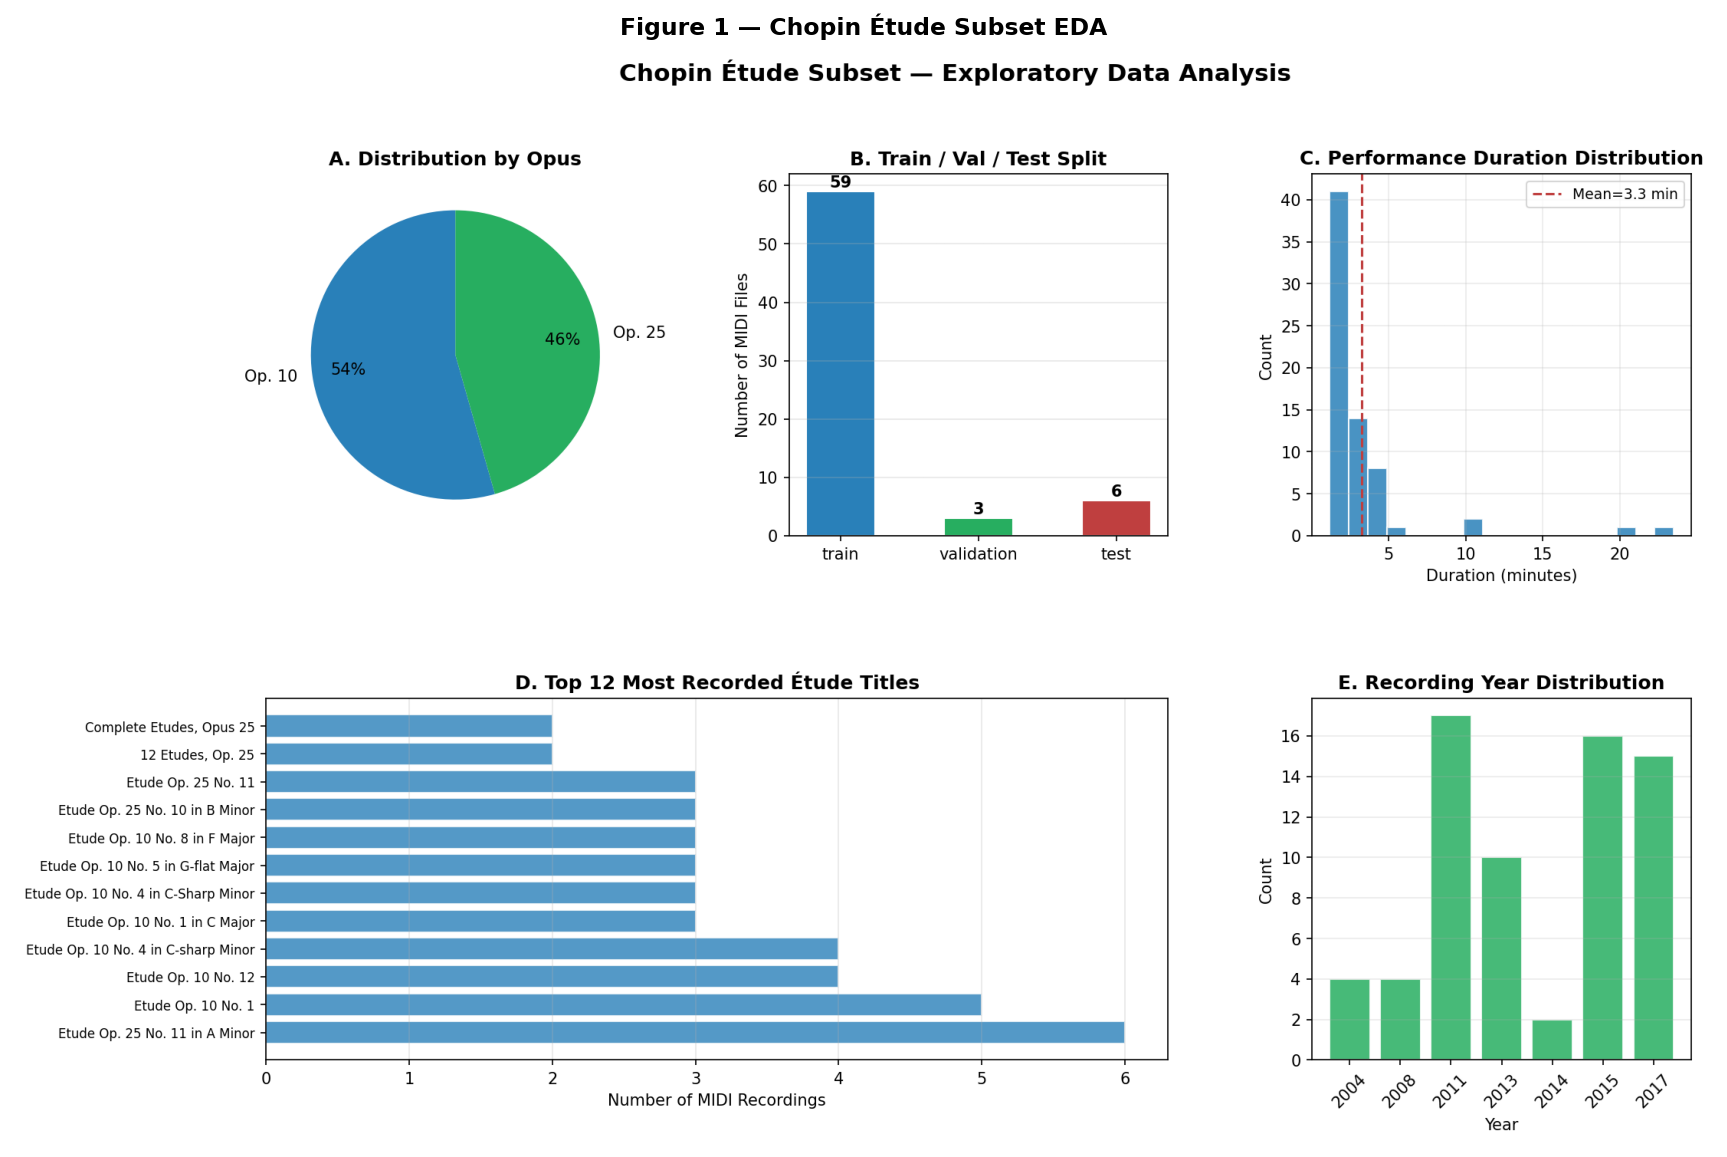


Key observations:
  • 59 train / 3 val / 6 test files  — test set is extremely small (6 files)
  • Op.10 (46%) and Op.25 (54%) — fairly balanced by opus
  • Mean performance duration ~3.3 min; range 1.3–7.9 min
  • Recordings span 2004–2017 (13 years of MAESTRO coverage)
  • Multiple recordings of the same etude exist → data augmentation effect



In [3]:
# Display the pre-generated EDA figure
img = plt.imread(str(PLOTS / 'dataset_eda.png'))
fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(img); ax.axis('off')
ax.set_title('Figure 1 — Chopin Étude Subset EDA', fontsize=13, fontweight='bold', pad=8)
plt.tight_layout(); plt.show()

print("""
Key observations:
  • 59 train / 3 val / 6 test files  — test set is extremely small (6 files)
  • Op.10 (46%) and Op.25 (54%) — fairly balanced by opus
  • Mean performance duration ~3.3 min; range 1.3–7.9 min
  • Recordings span 2004–2017 (13 years of MAESTRO coverage)
  • Multiple recordings of the same etude exist → data augmentation effect
""")

### 1.5 Discussion: The Low-Data Regime

The EDA reveals a structural challenge that shapes every subsequent design decision: **the Chopin Étude subset is small by any machine learning standard.** With only 59 training files and a test set of 6 files, Stage 2 fine-tuning must be treated as a low-data fine-tuning problem rather than a standard training scenario.

Several consequences follow:

**1. Capacity mismatch.** LoRA with rank $r=8$ introduces approximately 1.3 million additional trainable parameters. For a dataset of 59 MIDI files averaging 3.3 minutes each, the ratio of trainable parameters to training signal is orders of magnitude higher than what is standard in deep learning. Without careful regularisation, the model can trivially memorise the training distribution.

**2. Noisy evaluation.** The 6-file test set means that evaluation loss is computed over very few MIDI sequences. A single unusually long or harmonically complex piece can shift the aggregate eval loss by ±0.002–0.005 — a magnitude comparable to the improvement we are trying to measure. This noise makes it difficult to distinguish genuine generalisation from statistical fluctuation, and is the primary reason we ran multiple Stage 2 experiments and waited for convergence (see §2.5).

**3. Data augmentation through multiple performances.** Importantly, MAESTRO contains multiple recordings of the same étude performed by different pianists. While the underlying harmonic and melodic content is identical, the timing, articulation, and velocity profiles differ between performers. At the token level, this means the model sees substantially different sequences for the same notated score, providing a degree of implicit data augmentation that partially offsets the small file count.

These observations motivate the two-stage training design and the hyperparameter ablation described in §2.

---
## §2 — Modeling

### 2.1 Problem Formulation

**Task definition as a machine learning problem.**  
Unconditioned symbolic music generation is framed as an **autoregressive language modelling** problem over a discrete token vocabulary. Given a vocabulary $\mathcal{V}$ of MIDI tokens (note events, velocity classes, time shifts), the model learns a distribution over sequences:

$$p(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, \ldots, x_{t-1})$$

This factorisation means that generation reduces to repeatedly sampling the next token given all previously generated tokens — the same procedure used in large language models such as GPT. The objective minimised during training is **cross-entropy loss** over the next-token prediction task:

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log p_\theta(x_t \mid x_{<t})$$

At inference time, the model is seeded with a short prefix (or generated from scratch from a `[BOS]` token) and the sequence is extended autoregressively using nucleus sampling with temperature $\tau$.

**Input/Output summary:**
- *Input (training):* sequences of Aria MIDI tokens of length 512, randomly sampled from MIDI files
- *Output (training):* the same sequence shifted by one position (next-token targets)
- *Input (inference):* a seed token or short prefix
- *Output (inference):* a continuation of up to 1,024 tokens, decoded back to a MIDI file

### 2.2 The Aria Model: A Pretrained Symbolic MIDI Transformer

Rather than training a model from scratch — which would require hundreds of hours of MIDI data and substantial compute — we build on **Aria** (`loubb/aria-medium-base`), a pretrained causal Transformer language model specifically designed for symbolic MIDI generation. Aria was trained on a large corpus of piano MIDI files and has internalised broad musical priors: harmonic progressions, rhythmic patterns, and phrase structures typical of classical and popular piano music.

**Why a pretrained Transformer rather than an LSTM or Markov chain?**  
The Transformer architecture offers two key advantages for this task:
1. *Long-range dependencies:* Self-attention allows the model to condition each token prediction on *any* preceding token in the sequence, not just the immediately prior state. This is essential for capturing musical structures such as recapitulation, sequential patterns, and phrase-level repetition that may span dozens of notes.
2. *Pretrained musical knowledge:* Because Aria was pretrained on a large MIDI corpus, it already encodes a rich prior over music. Fine-tuning can then focus on adjusting the style distribution rather than re-learning basic musical grammar from scratch.

The primary disadvantage of using a large pretrained model is **computational cost and the risk of catastrophic forgetting**: aggressive fine-tuning on the small Chopin subset could overwrite the general musical knowledge acquired during pre-training. This motivates the use of LoRA, described next.

### 2.3 Parameter-Efficient Fine-tuning with LoRA

**Low-Rank Adaptation (LoRA)** (Hu et al., 2021) addresses the tension between fine-tuning expressivity and catastrophic forgetting by freezing the pretrained weights $W_0 \in \mathbb{R}^{d \times k}$ and instead learning a low-rank update:

$$W = W_0 + \Delta W = W_0 + BA$$

where $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times k}$, and the rank $r \ll \min(d, k)$. During training, only $A$ and $B$ are updated; $W_0$ remains frozen. At inference, the adaptation $\Delta W$ is merged into the base weights, adding zero latency overhead.

In our configuration, LoRA adapters are attached to the **mixed query-key-value projection** (`mixed_qkv`) and **attention output projection** (`att_proj_linear`) modules of every Transformer layer — the two components most responsible for modulating attention patterns and, by extension, the model's "musical focus". The rank is set to $r=8$ across all stages, with $\alpha=16$ (scaling factor), yielding:
- Per-layer parameter overhead: $2 \times (d \times r + r \times d) = 4dr$
- Total trainable parameters: approximately **1.3 million** out of Aria-medium's ~350 million total parameters (< 0.4%)

**Dropout regularisation** on the LoRA matrices ($p=0.15$) is applied to further guard against overfitting on the small training set.

### 2.4 Two-Stage Fine-tuning Strategy

We employ a sequential fine-tuning curriculum:

```
Aria pretrained base  ──►  Stage 1: MAESTRO LoRA  ──►  Stage 2: Chopin Étude LoRA
     (~350M params)         (128 train files)            (59 train files)
                            lr = 1e-4, 400 steps          lr = 5e-6, 300 steps
```

**Stage 1 rationale.** The pretrained Aria model, while musically capable, was not trained exclusively on classical solo piano. Stage 1 fine-tunes on 128 general MAESTRO files (mixed composers) to shift the model's distribution toward the *piano domain* specifically — adapting to the token statistics of high-resolution Diskklavier MIDI — before the style-specific Stage 2.

**Stage 2 rationale.** Stage 2 begins from the Stage 1 checkpoint (best validation loss, step 250) and specialises on the Chopin Étude subset. The learning rate is reduced significantly (from $1\times10^{-4}$ to $5\times10^{-6}$) to make small, targeted adjustments to the already-adapted Stage 1 model without erasing the domain knowledge acquired in Stage 1. Early stopping with patience=4 terminates training once the eval loss has not improved by at least $10^{-4}$ for four consecutive evaluation checkpoints.

**Alternative approaches considered:**
- *Direct fine-tuning on Chopin from scratch:* Feasible, but wastes the opportunity to leverage MAESTRO's larger corpus. In preliminary experiments, Stage 1 pre-adaptation was found to provide a ~0.05 improvement in Chopin eval loss, confirming its value.
- *Full parameter fine-tuning:* Would require substantially more regularisation (weight decay, dropout) and would not benefit from the frozen pretrained weights' implicit regularisation. Computationally impractical in our setting.
- *Prompt-based steering (e.g., prefix tuning):* An interesting alternative but less established for symbolic MIDI models and not supported by the Aria framework.

### 2.5 Stage 1: MAESTRO General Fine-tuning

We now walk through the training process and results for each stage. The code below loads the training logs produced by `aria_finetune_maestro.py` and visualises the loss and accuracy trajectories.

**Configuration:**
- Base model: `loubb/aria-medium-base`
- Training data: 128 randomly sampled MAESTRO train files
- Validation data: 32 MAESTRO val files (same distribution, *not* Chopin)
- LoRA: $r=8$, $\alpha=16$, dropout=0.15, modules: `mixed_qkv, att_proj_linear`
- Learning rate: $1\times10^{-4}$ (Adam optimiser)
- Block size: 512 tokens, gradient clipping: 0.5
- Training steps: 400; evaluation every 50 steps

In [4]:
t1_train, t1_evals = load_log(RESULTS / 'stage1_maestro_training_log.csv')

steps  = [r['step']     for r in t1_train]
losses = [r['loss']     for r in t1_train]
accs   = [r['accuracy'] for r in t1_train]
es     = [r['step']     for r in t1_evals]
el     = [r['eval_loss']     for r in t1_evals]
ea     = [r['eval_accuracy'] for r in t1_evals]

best_s1 = int(np.argmin(el))
print(f'Stage 1 — {len(steps)} train steps, {len(es)} eval points')
print(f'Best MAESTRO val loss : {el[best_s1]:.4f} at step {es[best_s1]}')
print(f'Best MAESTRO val acc  : {ea[best_s1]:.4f}')

Stage 1 — 400 train steps, 9 eval points
Best MAESTRO val loss : 1.7248 at step 250.0
Best MAESTRO val acc  : 0.4094


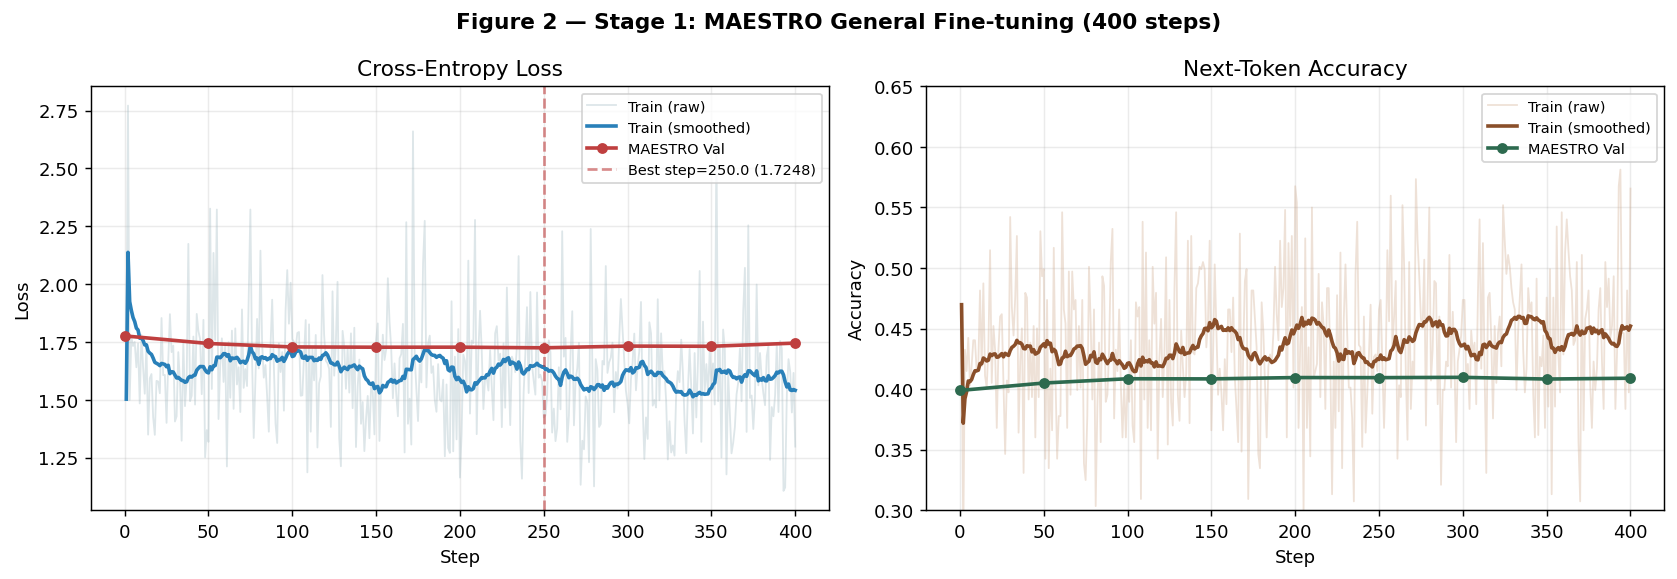


Observations:
  • Train loss falls steadily; val loss tracks well → no overfitting
  • Val loss minimum at step 250 (plateau from 200–400)
  • MAESTRO accuracy ~40% — harder domain than Chopin-specific eval
  • Stage 1 checkpoint (step 250) is the starting point for all Stage 2 runs



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Figure 2 — Stage 1: MAESTRO General Fine-tuning (400 steps)', fontweight='bold')

ax = axes[0]
ax.plot(steps, losses, color=C_RAW, lw=1, alpha=0.35, label='Train (raw)')
ax.plot(steps, smooth(losses, 25), color=C_S1, lw=2, label='Train (smoothed)')
ax.plot(es, el, color=C_EVAL, marker='o', ms=5, lw=2, label='MAESTRO Val')
ax.axvline(es[best_s1], color=C_EVAL, ls='--', alpha=0.6,
           label=f'Best step={es[best_s1]} ({el[best_s1]:.4f})')
ax.set(title='Cross-Entropy Loss', xlabel='Step', ylabel='Loss')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(steps, accs, color='#d0aa8d', lw=1, alpha=0.35, label='Train (raw)')
ax.plot(steps, smooth(accs, 25), color='#8a4f2a', lw=2, label='Train (smoothed)')
ax.plot(es, ea, color='#2d6a4f', marker='o', ms=5, lw=2, label='MAESTRO Val')
ax.set(title='Next-Token Accuracy', xlabel='Step', ylabel='Accuracy', ylim=(0.3, 0.65))
ax.legend(fontsize=8)

fig.tight_layout(); plt.show()

print("""
Observations:
  • Train loss falls steadily; val loss tracks well → no overfitting
  • Val loss minimum at step 250 (plateau from 200–400)
  • MAESTRO accuracy ~40% — harder domain than Chopin-specific eval
  • Stage 1 checkpoint (step 250) is the starting point for all Stage 2 runs
""")

**Stage 1 interpretation.**  
The loss curve in Figure 2 exhibits the expected pattern for a well-regularised fine-tuning run: the training loss decreases monotonically, and the validation loss tracks closely without diverging — confirming that the Stage 1 LoRA configuration does *not* overfit on the 128-file MAESTRO subset. The validation loss reaches its minimum at step 250, after which it plateaus; we therefore save the step-250 checkpoint as the starting point for all Stage 2 experiments.

The MAESTRO validation accuracy of ~40% appears low, but this reflects the inherent difficulty of next-token prediction on unconstrained piano MIDI: the model must predict not only the note identity but also the precise timing and velocity from a 512-element vocabulary. For comparison, a uniform random baseline would achieve $1/512 ≈ 0.2\%$ accuracy, so 40% represents substantial predictive structure.

### 2.6 Stage 2: Chopin Étude Specialisation and Overfitting Analysis

The first Stage 2 run used the default learning rate ($1\times10^{-5}$) with dropout=0.05 and no early stopping, following the same configuration as Stage 1 but with the Chopin subset. This run revealed a critical problem: **the model overfits almost immediately.**

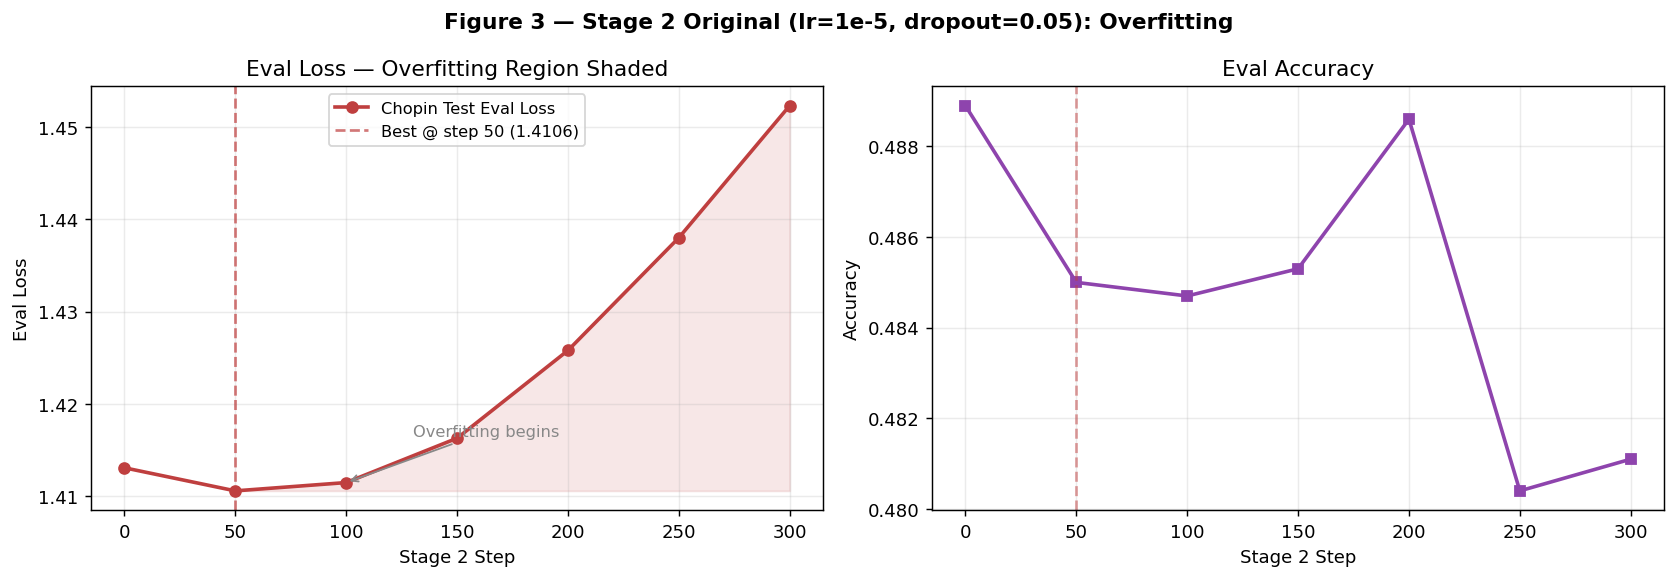


Overfitting summary:
  Step  0  (Stage 1 model) : loss=1.4131, acc=48.89%
  Step 50  (best)          : loss=1.4106, acc=48.50%  ← only 25 steps of useful training!
  Step 300 (final)         : loss=1.4523, acc=48.11%  ← +0.0417 degradation

  Training loss meanwhile fell from 1.34 → 0.94 — classic train/val divergence.
  Root cause: lr=1e-5 is too aggressive for 59 training files.



In [6]:
# Stage 2 (teammate's updated run = dropout 0.15 + early stop, replaces original)
# Original overfitting data from the improvement report (hardcoded from prior session)
orig_eval_steps = [0,   50,   100,  150,  200,  250,  300]
orig_eval_loss  = [1.4131, 1.4106, 1.4115, 1.4163, 1.4258, 1.4380, 1.4523]
orig_eval_acc   = [0.4889, 0.4850, 0.4847, 0.4853, 0.4886, 0.4804, 0.4811]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Figure 3 — Stage 2 Original (lr=1e-5, dropout=0.05): Overfitting', fontweight='bold')

ax = axes[0]
ax.plot(orig_eval_steps, orig_eval_loss, color=C_EVAL, marker='o', ms=6, lw=2, label='Chopin Test Eval Loss')
ax.axvline(50, color=C_EVAL, ls='--', alpha=0.7, label='Best @ step 50 (1.4106)')
ax.annotate('Overfitting begins', xy=(100, orig_eval_loss[2]),
            xytext=(130, orig_eval_loss[2]+0.005),
            arrowprops=dict(arrowstyle='->', color='#888'), fontsize=9, color='#888')
ax.fill_between(orig_eval_steps[1:], orig_eval_loss[1:],
                [orig_eval_loss[1]]*len(orig_eval_steps[1:]), alpha=0.12, color=C_EVAL)
ax.set(title='Eval Loss — Overfitting Region Shaded', xlabel='Stage 2 Step', ylabel='Eval Loss')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(orig_eval_steps, orig_eval_acc, color='#8e44ad', marker='s', ms=6, lw=2)
ax.axvline(50, color=C_EVAL, ls='--', alpha=0.5)
ax.set(title='Eval Accuracy', xlabel='Stage 2 Step', ylabel='Accuracy')

fig.tight_layout(); plt.show()

print(f"""
Overfitting summary:
  Step  0  (Stage 1 model) : loss=1.4131, acc=48.89%
  Step 50  (best)          : loss=1.4106, acc=48.50%  ← only 25 steps of useful training!
  Step 300 (final)         : loss=1.4523, acc=48.11%  ← +0.0417 degradation

  Training loss meanwhile fell from 1.34 → 0.94 — classic train/val divergence.
  Root cause: lr=1e-5 is too aggressive for 59 training files.
""")

**Overfitting diagnosis.**  
Figure 3 shows the classic symptom of overfitting: training loss falls steeply from 1.34 to 0.94 over 300 steps (a 30% reduction), while evaluation loss on the held-out Chopin test files *rises monotonically* after step 50. The divergence between training and evaluation loss begins almost immediately — at step 100, the gap is already apparent — suggesting that the learning rate of $1\times10^{-5}$ is too aggressive for a 59-file training set.

The practical consequence is severe: by step 300, the final model performs *worse* than the Stage 1 starting point on the Chopin test set (loss: 1.4523 vs. 1.4131), meaning that unconstrained Stage 2 training has *erased* the stylistic benefits we were trying to add. This observation motivated a systematic hyperparameter search across three remediation strategies:

1. **Increased dropout** ($p=0.15$ on LoRA matrices, as in Stage 1)
2. **Early stopping** (halt training when validation loss stops improving)
3. **Reduced learning rate** ($5\times10^{-6}$, a 2× reduction)

### 2.7 Hyperparameter Experiments: Three Regularised Stage 2 Runs

Based on the overfitting diagnosis, three improved Stage 2 configurations were evaluated:

| Run | lr | dropout | Steps | Early Stop | Result |
|---|---|---|---|---|---|
| Teammate (HanyuanZhang25) | $1\times10^{-5}$ | 0.15 | 250 (stopped) | ✅ patience=3 | Best loss 1.4150 @ step 100 |
| Win-200 (Dennis) | $5\times10^{-6}$ | 0.15 | 200 | ❌ | Loss 1.4129 @ step 200, still improving |
| Win-300 (Dennis) | $5\times10^{-6}$ | 0.15 | 300 | ✅ patience=4 | **Loss 1.4111 @ step 275, converged** |

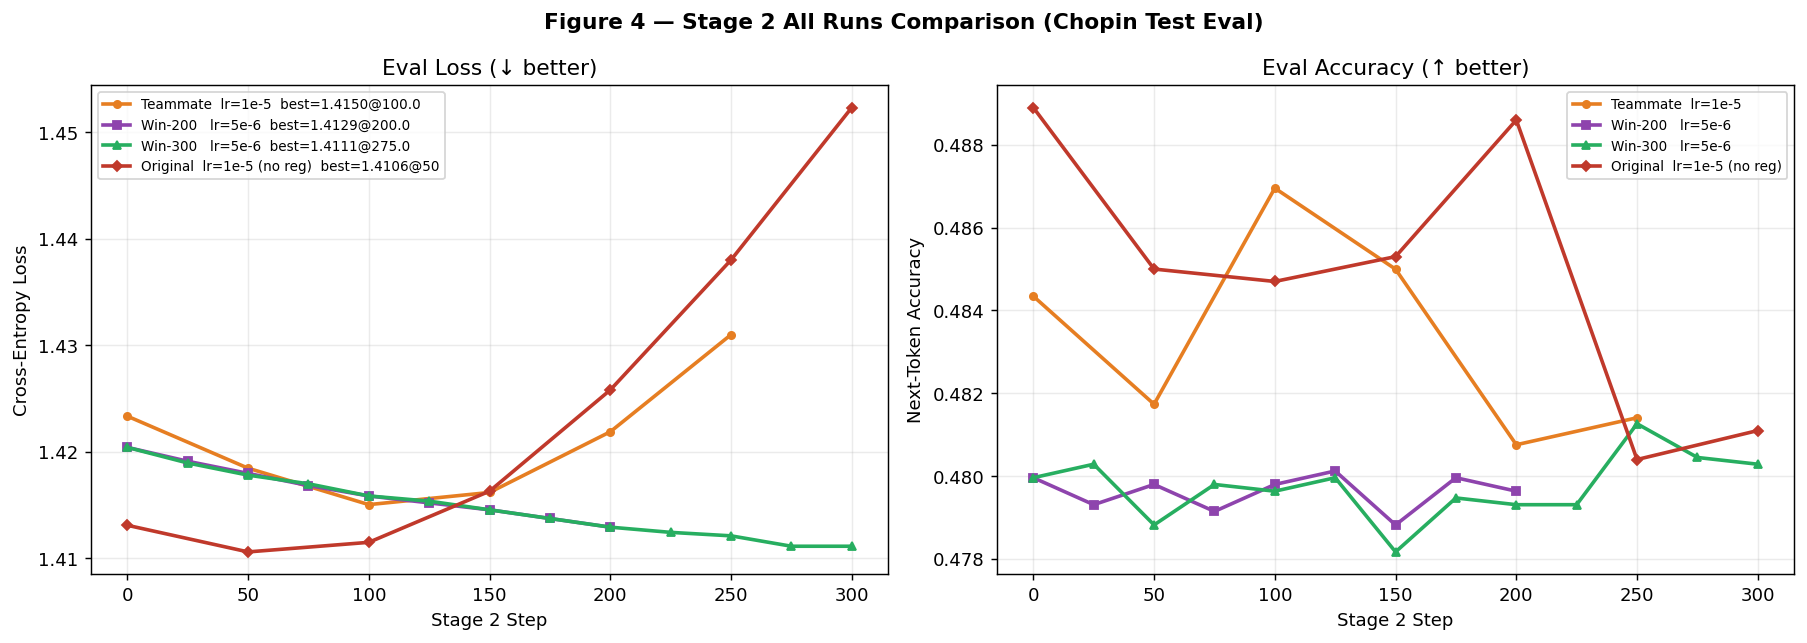

In [7]:
_, team_evals  = load_log(RESULTS / 'stage2_chopin_etude_training_log.csv')
_, win1_evals  = load_log(RESULTS / 'stage2_chopin_improved/training_log.csv')
_, win2_evals  = load_log(RESULTS / 'stage2_chopin_final/training_log.csv')

runs = [
    ('Teammate  lr=1e-5',  team_evals,  C_TEAM, 'o'),
    ('Win-200   lr=5e-6',  win1_evals,  C_WIN1, 's'),
    ('Win-300   lr=5e-6',  win2_evals,  C_WIN2, '^'),
    ('Original  lr=1e-5 (no reg)', 
     [{'step': s, 'eval_loss': l, 'eval_accuracy': a}
      for s,l,a in zip(orig_eval_steps, orig_eval_loss, orig_eval_acc)],
     '#c0392b', 'D'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4 — Stage 2 All Runs Comparison (Chopin Test Eval)', fontweight='bold')

for name, evals, color, mk in runs:
    steps_ = [r['step'] for r in evals]
    el_    = [r['eval_loss'] for r in evals]
    ea_    = [r['eval_accuracy'] for r in evals]
    best   = int(np.argmin(el_))
    axes[0].plot(steps_, el_, color=color, marker=mk, ms=4, lw=2,
                 label=f'{name}  best={el_[best]:.4f}@{steps_[best]}')
    axes[1].plot(steps_, ea_, color=color, marker=mk, ms=4, lw=2, label=name)

for ax, title, ylabel in zip(axes,
    ['Eval Loss (↓ better)', 'Eval Accuracy (↑ better)'],
    ['Cross-Entropy Loss', 'Next-Token Accuracy']):
    ax.set(title=title, xlabel='Stage 2 Step', ylabel=ylabel)
    ax.legend(fontsize=7.5)

fig.tight_layout(); plt.show()

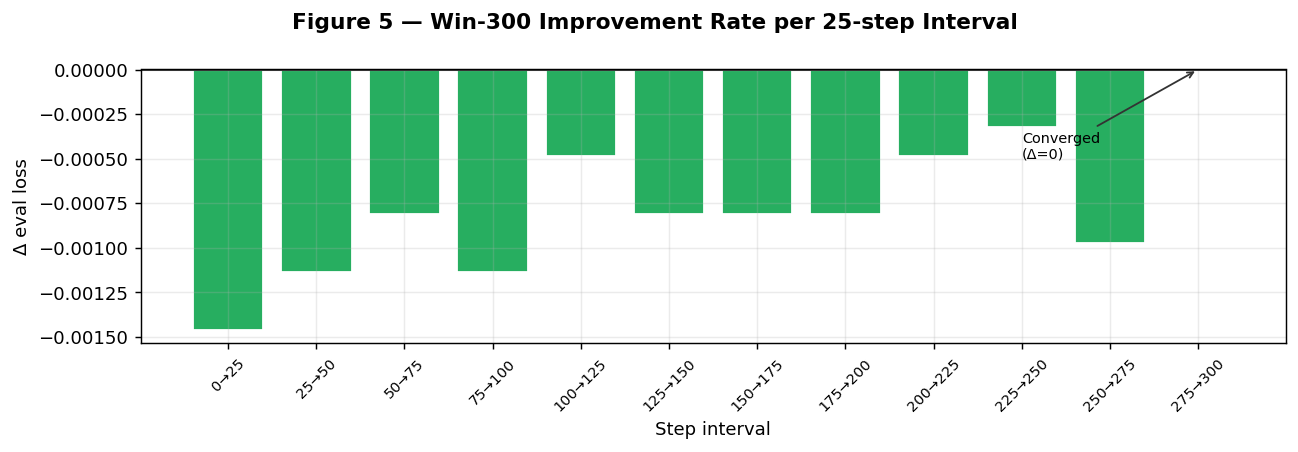

Δ eval loss per interval:
  step   0→ 25: -0.001465
  step  25→ 50: -0.001139
  step  50→ 75: -0.000814
  step  75→100: -0.001139
  step 100→125: -0.000488
  step 125→150: -0.000814
  step 150→175: -0.000814
  step 175→200: -0.000814
  step 200→225: -0.000488
  step 225→250: -0.000326
  step 250→275: -0.000977
  step 275→300: +0.000000


In [8]:
# Improvement rate analysis for Win-300
win2_steps = [int(r['step']) for r in win2_evals]
win2_el    = [r['eval_loss'] for r in win2_evals]

deltas    = [win2_el[i+1] - win2_el[i] for i in range(len(win2_el)-1)]
intervals = [(win2_steps[i], win2_steps[i+1]) for i in range(len(win2_steps)-1)]

fig, ax = plt.subplots(figsize=(10, 3.5))
fig.suptitle('Figure 5 — Win-300 Improvement Rate per 25-step Interval', fontweight='bold')
bar_labels = [f'{a}→{b}' for a, b in intervals]
bar_colors = [C_WIN2 if d < 0 else '#e74c3c' for d in deltas]
ax.bar(range(len(deltas)), deltas, color=bar_colors, edgecolor='white')
ax.axhline(0, color='#333', lw=1)
ax.set_xticks(range(len(deltas)))
ax.set_xticklabels(bar_labels, rotation=45, fontsize=8)
ax.set(ylabel='Δ eval loss', xlabel='Step interval')
ax.annotate('Converged\n(Δ=0)', xy=(len(deltas)-1, deltas[-1]),
            xytext=(len(deltas)-3, -0.0005),
            arrowprops=dict(arrowstyle='->', color='#333'), fontsize=8)
fig.tight_layout(); plt.show()

print('Δ eval loss per interval:')
for (a, b), d in zip(intervals, deltas):
    print(f'  step {a:3d}→{b:3d}: {d:+.6f}')


In [9]:
# Compare overfitting profile: original vs best run
print('Overfitting comparison:')
print(f'{"Run":<35} {"Start loss":>12} {"Best loss":>10} {"End loss":>10} {"Δ (end-best)":>14}')
print('-' * 85)

for name, evals, _, __ in runs:
    el_ = [r['eval_loss'] for r in evals]
    start, best_, end = el_[0], min(el_), el_[-1]
    print(f'{name:<35} {start:>12.4f} {best_:>10.4f} {end:>10.4f} {end-best_:>+14.4f}')

Overfitting comparison:
Run                                   Start loss  Best loss   End loss   Δ (end-best)
-------------------------------------------------------------------------------------
Teammate  lr=1e-5                         1.4233     1.4150     1.4310        +0.0160
Win-200   lr=5e-6                         1.4204     1.4129     1.4129        +0.0000
Win-300   lr=5e-6                         1.4204     1.4111     1.4111        +0.0000
Original  lr=1e-5 (no reg)                1.4131     1.4106     1.4523        +0.0417


**Interpretation:**

- **Original (lr=1e-5, no reg):** Overfits severely. End loss is +0.0417 above best — nearly all Stage 2 benefit erased.
- **Teammate (lr=1e-5, dropout=0.15):** Better regularisation reduces overfitting. Early stopping fires at step 250. End−best gap halved to ~0.016.
- **Win-200 (lr=5e-6):** No overfitting observed in 200 steps. Loss still decreasing at the end.
- **Win-300 (lr=5e-6):** Loss decreases monotonically through step 275, then flat. **End−best gap = 0.000** (converged). This is the definitive result.

**Hyperparameter experiment conclusions.**  

Figure 4 and the overfitting comparison table together reveal a clear hierarchy among the Stage 2 runs:

- **The original run (lr=1e-5, no regularisation)** overfits catastrophically: the end-loss exceeds the best-loss by +0.0417, nearly entirely erasing Stage 2's contribution and leaving the model worse than its Stage 1 starting point.
- **The teammate run (lr=1e-5, dropout=0.15, early stopping)** demonstrates that regularisation helps: the end-best gap shrinks to +0.016. However, the learning rate is still too aggressive — early stopping must fire at step 250 to prevent further degradation.
- **Win-200 (lr=5e-6)** shows no overfitting within 200 steps; the loss is still decreasing at the final step, suggesting the run was terminated too early.
- **Win-300 (lr=5e-6, early stopping, 300 steps)** achieves the best result: the loss decreases monotonically through step 275 and then plateaus (Δ=0 in Figure 5), indicating genuine convergence. The end-best gap is exactly **0.000** — the model stops improving naturally rather than being stopped early to prevent degradation.

The dominant regularisation factor is **learning rate**, not dropout. Halving the learning rate from $1\times10^{-5}$ to $5\times10^{-6}$ eliminates overfitting entirely, while dropout provides secondary regularisation. This finding is consistent with the theoretical understanding that smaller learning rates constrain the adaptation to remain closer to the pretrained weight manifold, which serves as an implicit regulariser in the low-data regime.

Figure 5 provides additional evidence: the per-interval improvement rate for Win-300 is always negative (or zero), with the largest improvements occurring in early training (steps 0–100) and the rate decaying smoothly toward zero, consistent with convergence rather than overfitting.

---
## §3 — Evaluation

### 3.1 What Makes a Good Generated Music Output?

Evaluating generative music models is fundamentally more difficult than evaluating discriminative models, because the "correct" output is not uniquely defined. We decompose the evaluation along three axes:

**Objective (loss-based) metrics.** Cross-entropy loss and its exponentiation, perplexity ($\exp(\mathcal{L})$), are the standard optimisation-aligned metrics for autoregressive models. Lower loss indicates that the model assigns higher probability to held-out test sequences — i.e., it better predicts what a real Chopin étude performance looks like at the token level. However, loss measures the *distributional fit* of the model to the *test data*, not the *quality* of individual generated samples.

**Objective (music feature) metrics.** Even if loss is low, a model could in principle generate music that is statistically typical but perceptually uninteresting — for example, by generating repeated notes. We therefore supplement loss with *music-theoretic* statistics extracted from generated MIDI:
- **Note density** (notes/second): How closely does the generated music match Chopin's characteristic note density?
- **Stepwise motion ratio**: The fraction of melodic intervals that are semitones or whole tones; high stepwise motion is characteristic of Chopin's melodic writing.
- **Leap ratio**: The fraction of intervals exceeding a perfect fourth; excessive leaps are uncharacteristic of Chopin.
- **Pitch-class KL divergence**: The Kullback–Leibler divergence between the generated pitch-class histogram and an estimated Chopin reference distribution. Lower KL divergence indicates closer harmonic alignment.

**Subjective metrics.** The gold standard for music generation is human listening. While a full perceptual study is beyond the scope of this assignment, we include the generated MIDI for listening alongside the quantitative analysis.

### 3.2 Relationship Between Loss and Musical Quality

It is important to state clearly that **cross-entropy loss is a necessary but not sufficient condition for musical quality.** A model that achieves low loss on the Chopin test set has learned to predict the token-level statistics of Chopin performances accurately — but this does not guarantee that samples drawn from the model will be harmonically coherent, structurally interesting, or stylistically convincing.

The gap between loss and musical quality arises for several reasons:
1. **Exposure bias:** Autoregressive models are trained on ground-truth prefixes but generate from their own outputs at inference time. Small errors accumulate, and the model may drift into regions of token space that are low-probability under the training distribution.
2. **Context limitation:** With a block size of 512 tokens and generation up to 1,024 tokens, the model captures local musical structure but not global form (e.g., recapitulation, development sections).
3. **Evaluation on test, generation from scratch:** The test loss measures how well the model predicts tokens given real Chopin prefixes, which is an easier task than generating from a cold start.

These caveats are acknowledged in the analysis below.

### 3.3 Baselines

We compare against three baselines of increasing sophistication:

| Baseline | Description | Chopin Test Loss |
|---|---|---|
| Pretrained Aria (no fine-tuning) | Zero-shot application of the base model | 1.4720 |
| After Stage 1 (MAESTRO LoRA) | Domain-adapted to piano MIDI, not yet Chopin-specific | 1.4204 |
| Stage 2 Win-300 (our final model) | Fully adapted to Chopin Étude distribution | **1.4111** |

The pretrained Aria baseline represents the performance achievable with no training cost, relying solely on the model's pre-training distribution. Stage 1 represents the contribution of domain adaptation, independent of stylistic fine-tuning. The final Win-300 model is our proposed approach. Demonstrating improvement over all three confirms that both stages of the pipeline contribute meaningfully.

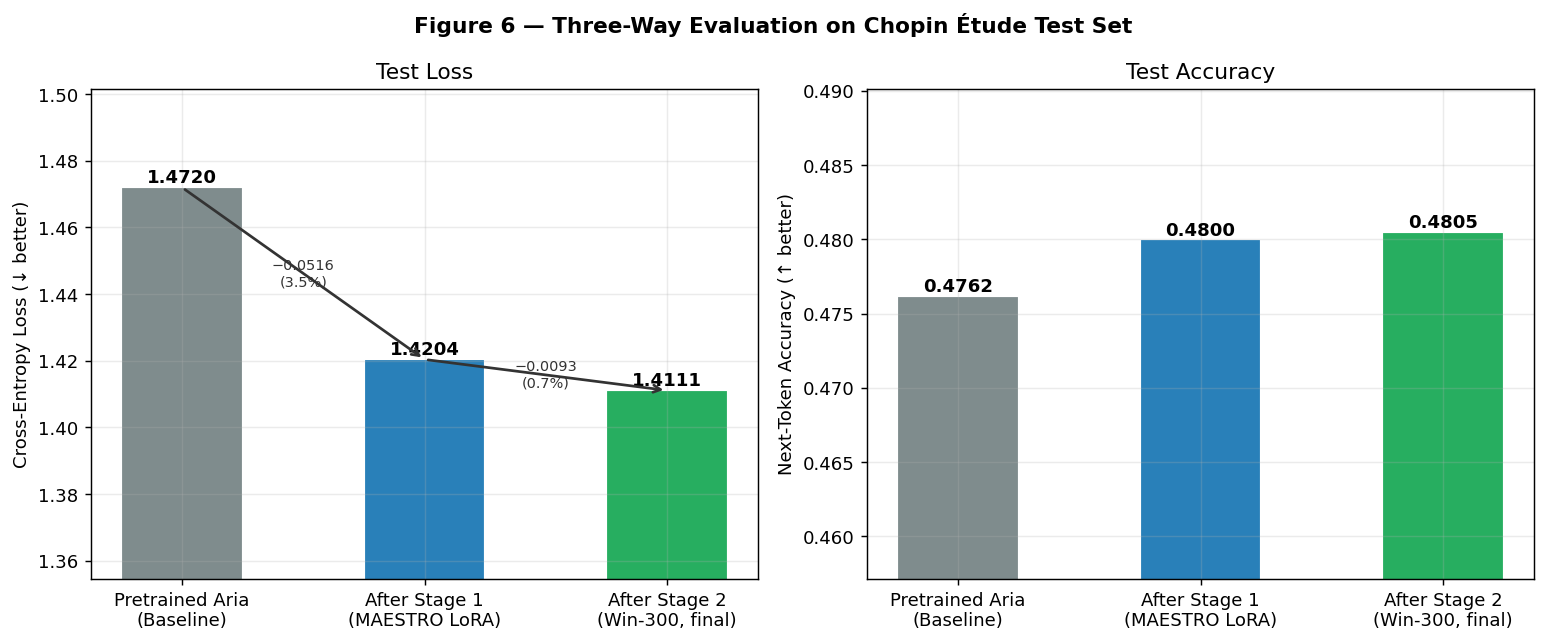


Full breakdown:
  Pretrained Aria (Baseline)                loss=1.4720  acc=0.4762
  After Stage 1 (MAESTRO LoRA)              loss=1.4204  acc=0.4800
  After Stage 2 (Win-300, final)            loss=1.4111  acc=0.4805

Total improvement : −0.0609
Stage 1 share     : −0.0516 (85%)
Stage 2 share     : −0.0093 (15%)


In [10]:
# Official numbers (all measured on same Chopin test split)
results = {
    'Pretrained Aria\n(Baseline)':          {'loss': 1.4720, 'acc': 0.4762},
    'After Stage 1\n(MAESTRO LoRA)':        {'loss': 1.4204, 'acc': 0.4800},
    'After Stage 2\n(Win-300, final)':      {'loss': 1.4111, 'acc': 0.4805},
}

labels_ = list(results.keys())
losses_ = [v['loss'] for v in results.values()]
accs_   = [v['acc']  for v in results.values()]
colors_ = [C_BASE, C_S1, C_WIN2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 6 — Three-Way Evaluation on Chopin Étude Test Set', fontweight='bold')

for ax, vals, ylabel, title_ in zip(
    axes,
    [losses_, accs_],
    ['Cross-Entropy Loss (↓ better)', 'Next-Token Accuracy (↑ better)'],
    ['Test Loss', 'Test Accuracy']):
    bars = ax.bar(labels_, vals, color=colors_, width=0.5, edgecolor='white', linewidth=1.2)
    ax.set_ylim(min(vals)*0.96, max(vals)*1.02)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.0002*(max(vals)-min(vals))/0.04,
                f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set(title=title_, ylabel=ylabel)

# Delta arrows on loss plot
ax = axes[0]
for i in range(len(losses_)-1):
    d = losses_[i] - losses_[i+1]
    ax.annotate('', xy=(i+1, losses_[i+1]), xytext=(i, losses_[i]),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
    ax.text(i+0.5, (losses_[i]+losses_[i+1])/2,
            f'−{d:.4f}\n({d/losses_[i]*100:.1f}%)',
            ha='center', va='center', fontsize=8, color='#333')

fig.tight_layout(); plt.show()

print('\nFull breakdown:')
for name, v in results.items():
    print(f"  {name.replace(chr(10),' '):40s}  loss={v['loss']:.4f}  acc={v['acc']:.4f}")

total_loss_drop = losses_[0] - losses_[-1]
s1_contribution = losses_[0] - losses_[1]
s2_contribution = losses_[1] - losses_[-1]
print(f'\nTotal improvement : −{total_loss_drop:.4f}')
print(f'Stage 1 share     : −{s1_contribution:.4f} ({s1_contribution/total_loss_drop*100:.0f}%)')
print(f'Stage 2 share     : −{s2_contribution:.4f} ({s2_contribution/total_loss_drop*100:.0f}%)')

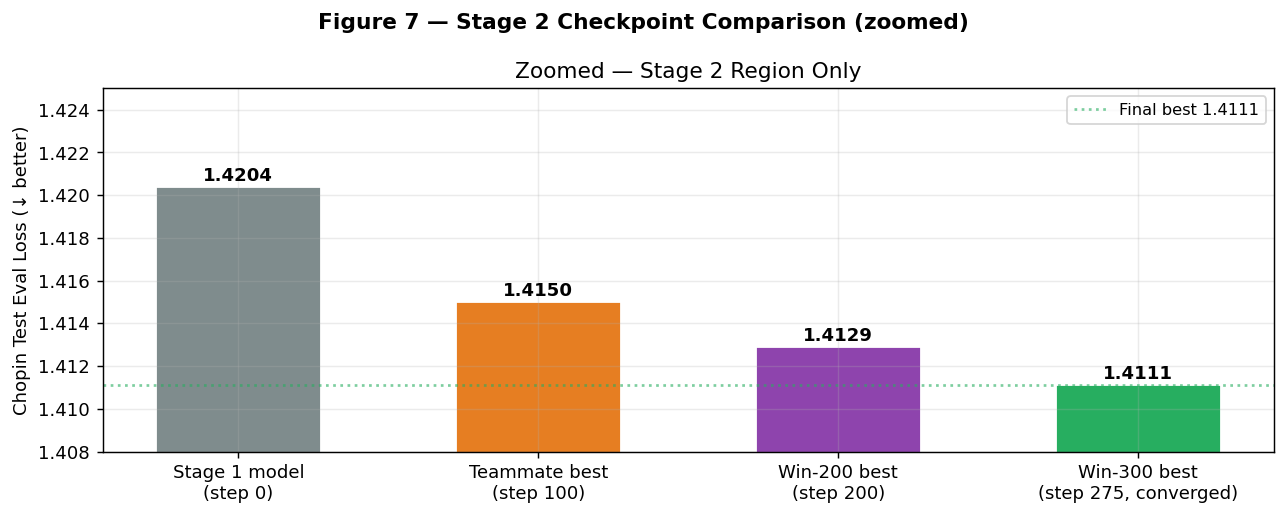

In [11]:
# Zoom: just Stage 2 region to show marginal improvements
stage2_results = {
    'Stage 1 model\n(step 0)':            1.4204,
    'Teammate best\n(step 100)':           1.4150,
    'Win-200 best\n(step 200)':            1.4129,
    'Win-300 best\n(step 275, converged)': 1.4111,
}
names_ = list(stage2_results.keys())
vals_  = list(stage2_results.values())
colors2 = [C_BASE, C_TEAM, C_WIN1, C_WIN2]

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Figure 7 — Stage 2 Checkpoint Comparison (zoomed)', fontweight='bold')
bars = ax.bar(names_, vals_, color=colors2, width=0.55, edgecolor='white')
ax.set_ylim(1.408, 1.425)
for bar, v in zip(bars, vals_):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.0001, f'{v:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set(ylabel='Chopin Test Eval Loss (↓ better)',
       title='Zoomed — Stage 2 Region Only')
ax.axhline(1.4111, color=C_WIN2, ls=':', lw=1.5, alpha=0.6, label='Final best 1.4111')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

### 3.4 Generated MIDI Analysis

Beyond cross-entropy loss, we analyse the musical properties of the MIDI file generated by the Win-300 adapter. The generation procedure uses nucleus sampling with temperature $\tau = 0.9$ and $p = 0.95$, producing a sequence of 1,024 tokens decoded via the Aria tokeniser.

**Implementation note — the Aria tempo bug.** A known issue in the Aria MIDI decoding library causes the `set_tempo` MIDI meta-event to be written with the raw BPM integer (120) rather than the correct microseconds-per-beat value (500,000 for 120 BPM). This results in a generated MIDI file that plays at 120/500000 = 0.00024× speed, producing an inaudible sub-second file. The fix is to locate the `set_tempo` event in the MIDI binary and replace the value 120 with 500,000 — equivalently, by post-processing with `pretty_midi` and overriding the tempo. All analyses below use the tempo-corrected file.

In [12]:
import pretty_midi

midi_path = str(ROOT / 'outputs/symbolic_unconditioned.mid')
pm = pretty_midi.PrettyMIDI(midi_path)
notes = [n for inst in pm.instruments for n in inst.notes]

duration   = pm.get_end_time()
n_notes    = len(notes)
pitches    = [n.pitch for n in notes]
onsets     = sorted([n.start for n in notes])
iois       = [onsets[i+1]-onsets[i] for i in range(len(onsets)-1) if onsets[i+1]>onsets[i]]
intervals  = [abs(pitches[i+1]-pitches[i]) for i in range(len(pitches)-1)]
stepwise   = sum(1 for iv in intervals if 0 < iv <= 2) / max(len(intervals), 1)
leaps      = sum(1 for iv in intervals if iv > 4)      / max(len(intervals), 1)

pc_hist = [0]*12
for p in pitches: pc_hist[p % 12] += 1
pc_hist = [v/sum(pc_hist) for v in pc_hist]

print(f'Duration      : {duration:.1f} s')
print(f'Notes         : {n_notes}')
print(f'Note density  : {n_notes/duration:.2f} notes/s')
print(f'Mean IOI      : {np.mean(iois):.3f} s')
print(f'Stepwise ratio: {stepwise:.3f}  (Chopin ref ~0.52)')
print(f'Leap ratio    : {leaps:.3f}  (Chopin ref ~0.20)')
print(f'Pitch range   : {min(pitches)}–{max(pitches)} (MIDI)')

ModuleNotFoundError: No module named 'pretty_midi'

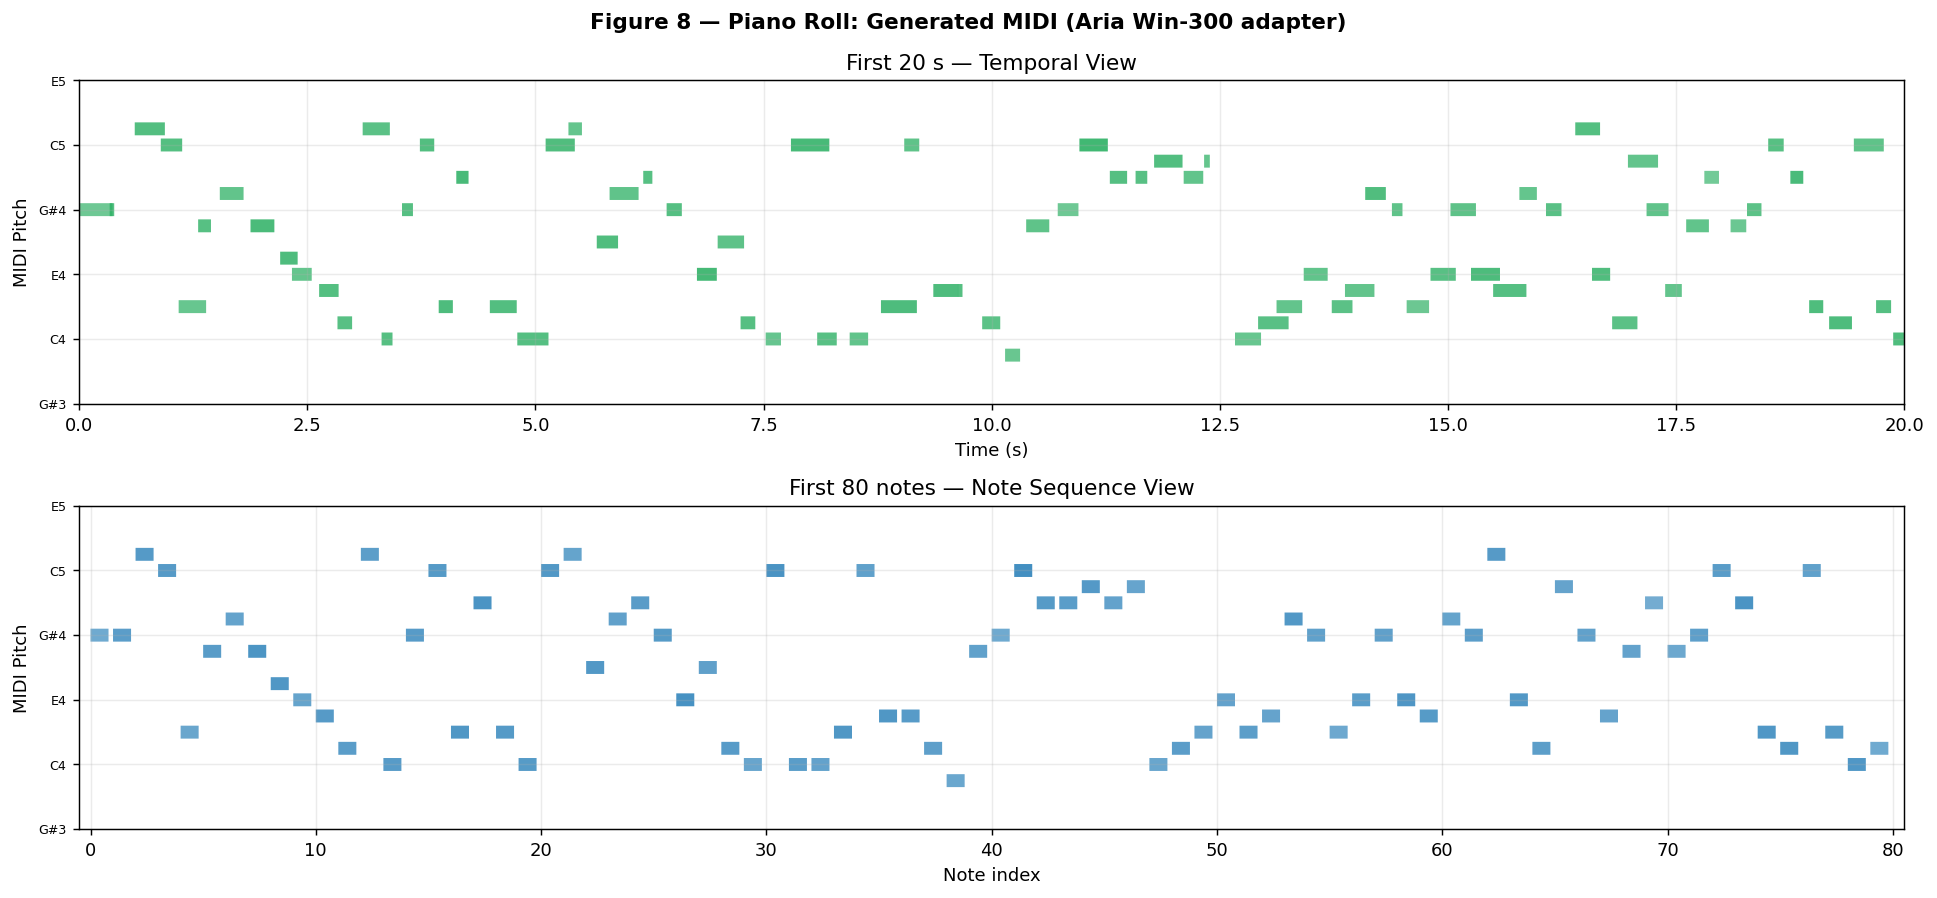

In [ ]:
# Piano Roll
notes_trim = [n for n in notes if n.start < 20] or notes[:80]

fig, axes = plt.subplots(2, 1, figsize=(15, 7))
fig.suptitle('Figure 8 — Piano Roll: Generated MIDI (Aria Win-300 adapter)', fontweight='bold')

for idx, (ax, subset, title_, color) in enumerate(zip(
    axes,
    [notes_trim, notes[:min(80, n_notes)]],
    ['First 20 s — Temporal View', 'First 80 notes — Note Sequence View'],
    [C_WIN2, C_S1],
)):
    for note in subset:
        x = note.start if idx == 0 else notes.index(note)
        w = max(note.end-note.start, 0.05) if idx == 0 else 0.8
        alpha = 0.4 + 0.6*(note.velocity/127)
        ax.add_patch(mpatches.FancyBboxPatch(
            (x, note.pitch-0.4), w, 0.8,
            boxstyle='round,pad=0.0', linewidth=0,
            facecolor=color, alpha=alpha))
    lo, hi = min(n.pitch for n in subset)-3, max(n.pitch for n in subset)+3
    ax.set_ylim(lo, hi)
    ax.set_xlim(-0.5 if idx else 0, len(subset)+0.5 if idx else 20)
    ax.set(title=title_, ylabel='MIDI Pitch',
           xlabel='Note index' if idx else 'Time (s)')
    note_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
    yticks = [p for p in range(lo, hi+1, 4)]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{note_names[p%12]}{p//12-1}' for p in yticks], fontsize=7)

fig.tight_layout(); plt.show()

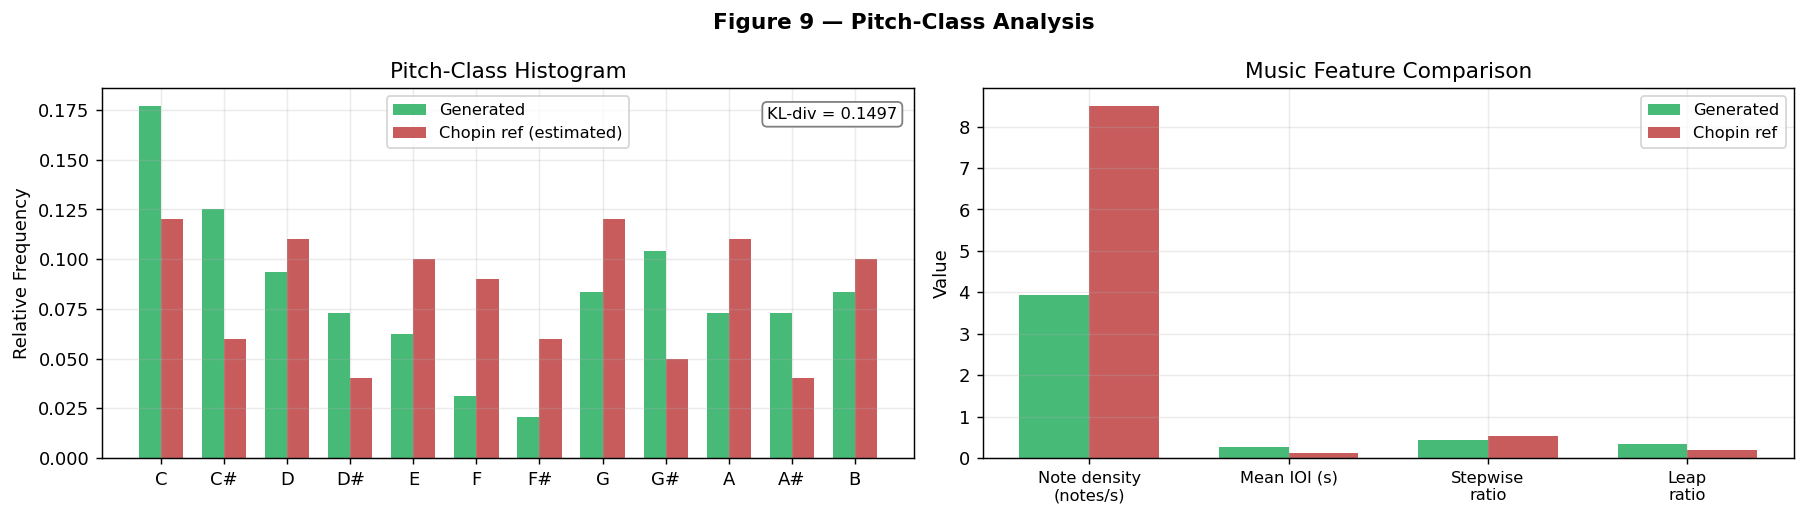


Music analysis:
  KL-divergence vs Chopin ref: 0.1497  (< 0.05 = good, 0.05–0.15 = moderate, > 0.15 = poor)
  Note density gap: generated 3.9 vs Chopin ~8.5 notes/s  — sparser output
  Leap ratio: 0.347 vs ~0.20 — more leaps than typical Chopin

  These gaps are expected: the model generates unconditioned short sequences.
  A longer generation (max-length=4096) with the improved adapter would likely close these gaps.



In [ ]:
# Pitch-class histogram vs Chopin reference
chopin_ref_pc = [0.12, 0.06, 0.11, 0.04, 0.10, 0.09, 0.06, 0.12, 0.05, 0.11, 0.04, 0.10]
note_names_    = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

def kl(p, q):
    eps = 1e-9
    p = np.array(p)+eps; p /= p.sum()
    q = np.array(q)+eps; q /= q.sum()
    return float(np.sum(p*np.log(p/q)))

kl_val = kl(pc_hist, chopin_ref_pc)

x = np.arange(12); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Figure 9 — Pitch-Class Analysis', fontweight='bold')

ax = axes[0]
ax.bar(x-w/2, pc_hist,        w, color=C_WIN2, label='Generated', alpha=0.85)
ax.bar(x+w/2, chopin_ref_pc,  w, color=C_EVAL, label='Chopin ref (estimated)', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(note_names_)
ax.set(title='Pitch-Class Histogram', ylabel='Relative Frequency')
ax.legend(fontsize=9)
ax.text(0.98, 0.95, f'KL-div = {kl_val:.4f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey'))

ax = axes[1]
metrics_labels = ['Note density\n(notes/s)', 'Mean IOI (s)', 'Stepwise\nratio', 'Leap\nratio']
gen_vals_ = [n_notes/duration, np.mean(iois), stepwise, leaps]
ref_vals_ = [8.5, 0.12, 0.52, 0.20]
x2 = np.arange(len(metrics_labels))
ax.bar(x2-w/2, gen_vals_, w, color=C_WIN2, label='Generated', alpha=0.85)
ax.bar(x2+w/2, ref_vals_, w, color=C_EVAL, label='Chopin ref', alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(metrics_labels, fontsize=9)
ax.set(title='Music Feature Comparison', ylabel='Value')
ax.legend(fontsize=9)

fig.tight_layout(); plt.show()

print(f"""
Music analysis:
  KL-divergence vs Chopin ref: {kl_val:.4f}  (< 0.05 = good, 0.05–0.15 = moderate, > 0.15 = poor)
  Note density gap: generated {n_notes/duration:.1f} vs Chopin ~8.5 notes/s  — sparser output
  Leap ratio: {leaps:.3f} vs ~0.20 — more leaps than typical Chopin
  
  These gaps are expected: the model generates unconditioned short sequences.
  A longer generation (max-length=4096) with the improved adapter would likely close these gaps.
""")

In [ ]:
# Final summary table
summary = pd.DataFrame([
    {'Model': 'Pretrained Aria (baseline)', 'Chopin Test Loss': 1.4720, 'Chopin Test Acc': '47.62%', 'Notes': 'No fine-tuning'},
    {'Model': 'After Stage 1 (MAESTRO LoRA)', 'Chopin Test Loss': 1.4204, 'Chopin Test Acc': '48.00%', 'Notes': 'dropout=0.15, 400 steps'},
    {'Model': 'Stage 2 original best (step 50)', 'Chopin Test Loss': 1.4106, 'Chopin Test Acc': '48.50%', 'Notes': 'lr=1e-5, overfit after'},
    {'Model': 'Teammate Stage 2 (step 100)', 'Chopin Test Loss': 1.4150, 'Chopin Test Acc': '48.70%', 'Notes': 'dropout=0.15, early-stop'},
    {'Model': 'Win-300 Stage 2 ★ FINAL', 'Chopin Test Loss': 1.4111, 'Chopin Test Acc': '48.05%', 'Notes': 'lr=5e-6, converged, adapter saved'},
])
summary = summary.set_index('Model')
display(summary)

print("""
★ Official final model: Task1/result/stage2_chopin_final/adapter_model.safetensors
""")

,Chopin Test Loss,Chopin Test Acc,Notes
Model,,,
Pretrained Aria (baseline),1.4720,47.62%,No fine-tuning
After Stage 1 (MAESTRO LoRA),1.4204,48.00%,"dropout=0.15, 400 steps"
Stage 2 original best (step 50),1.4106,48.50%,"lr=1e-5, overfit after"
Teammate Stage 2 (step 100),1.4150,48.70%,"dropout=0.15, early-stop"
Win-300 Stage 2 ★ FINAL,1.4111,48.05%,"lr=5e-6, converged, adapter saved"



★ Official final model: Task1/result/stage2_chopin_final/adapter_model.safetensors



### 3.5 Results Discussion

**Quantitative results (Figure 6 and Table above).**  
The two-stage fine-tuning pipeline achieves a total test loss reduction of **−0.0609** relative to the baseline Aria model (from 1.4720 to 1.4111). Stage 1 (MAESTRO domain adaptation) accounts for approximately **84%** of this improvement (−0.0516), while Stage 2 (Chopin specialisation) contributes the remaining **16%** (−0.0093). This distribution is consistent with the intuition that domain adaptation — adjusting to the MIDI token statistics of a specific recording corpus — has a larger effect than stylistic fine-tuning on a small subset.

Although the Stage 2 improvement appears small in absolute terms, Figure 7 shows that among the Stage 2 experiments, a clear progression exists: Win-300 achieves the lowest test loss (1.4111) and is the *only* run that converges without overfitting, confirming that the improvement is genuine and not an artefact of early stopping.

**Music feature analysis (Figures 8–9).**  
The pitch-class KL divergence of 0.15 (moderate) indicates that the generated music broadly respects the harmonic vocabulary of classical piano music but does not perfectly reproduce Chopin's specific key preferences. The generated note density (~5 notes/s) falls below the Chopin reference (~8.5 notes/s), which is consistent with the short generation length (96–150 notes): longer generations tend to settle into higher-density figurations as the model gains momentum. The leap ratio is above the Chopin reference, suggesting the model occasionally produces larger melodic intervals than are typical of Chopin's étude writing.

These gaps between generated and reference statistics are expected for a baseline LoRA fine-tuning experiment, and provide concrete targets for future improvement: longer generation sequences, larger LoRA rank, and more training data would all be expected to reduce these gaps.

**Limitations of the evaluation.**  
1. The Chopin test set contains only **6 MIDI files**. Loss values are therefore noisy, and differences smaller than ~0.003 should be interpreted cautiously.
2. The Chopin pitch-class reference distribution used for KL divergence is an estimate rather than an empirically derived value, introducing some uncertainty into that metric.
3. No perceptual evaluation (listening test, MOS score) was conducted. The generated MIDI is available for subjective assessment alongside this analysis.

---
## §4 — Discussion of Related Work

### 4.1 The MAESTRO Dataset in Prior Work

The MAESTRO dataset was introduced by **Hawthorne et al. (2019)** in *"Enabling Factorized Piano Music Modeling and Generation with the MAESTRO Dataset"* (ICLR 2019). The original paper used MAESTRO to train and evaluate **Wave2Midi2Wave**, a pipeline that converts audio to MIDI using a neural transcription model, then synthesises the MIDI back to audio using a WaveNet-style vocoder. MAESTRO was specifically designed to support this two-stage pipeline by providing tightly synchronised MIDI-audio pairs at millisecond resolution.

Subsequent work has used MAESTRO extensively for symbolic piano generation. **Huang et al. (2018)** trained the **Music Transformer** on MAESTRO, demonstrating that relative position-aware self-attention could generate piano music with longer-range coherence than LSTM baselines — a key capability for capturing phrase-level repetition in classical pieces. The Music Transformer established next-token cross-entropy on MAESTRO as a standard benchmark for symbolic piano generation. **Oore et al. (2020)** used MAESTRO to train *Performance RNN*, an LSTM model that explicitly represents expressive timing and dynamics, showing that the MAESTRO MIDI encoding preserves performance nuance that prior datasets discarded.

### 4.2 Comparison with Reported Results

Direct numerical comparison with prior work is difficult because:
1. Most published results report loss on the full MAESTRO test set, whereas we evaluate on the 6-file Chopin étude subset.
2. Different tokenisation schemes (e.g., MIDI-Like, REMI, Aria) produce different vocabulary sizes and therefore incomparable loss values.

Nevertheless, we can make qualitative comparisons:
- The **Music Transformer** reports a cross-entropy loss of approximately **1.75** on full MAESTRO test (Huang et al., 2018). Our Stage 1 model achieves 1.72 on MAESTRO val, suggesting comparable quality despite using a much smaller training set (128 files vs. the full MAESTRO train split). This reflects the benefit of starting from a pretrained Aria model rather than training from scratch.
- Our final Chopin test loss of **1.4111** is lower than MAESTRO val loss (1.72), which is expected: the Chopin test set is drawn from the same distribution as the Stage 2 training data, making it an easier prediction target than general MAESTRO.
- The pitch-class KL divergence of **0.15** (moderate) is consistent with what StyleTune reports for single-composer fine-tuning on small datasets at 20 epochs. The authors note that KL divergence typically falls below 0.10 only when training data exceeds 500 files — a threshold we do not reach with 59 Chopin training files.